In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

print("Project root:", project_root)

Project root: c:\Users\ASUS\Desktop\NLP-News-Intelligence


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
from datasets import load_from_disk

train_dataset = load_from_disk(
    "../data/splits/train"
)

val_dataset = load_from_disk(
    "../data/splits/validation"
)

test_dataset = load_from_disk(
    "../data/splits/test"
)

print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

c:\Users\ASUS\Desktop\NLP-News-Intelligence\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Training: 108000
Validation: 12000
Test: 7600


In [4]:
import json

with open(
    "../data/processed/vocab.json",
    "r",
    encoding="utf-8"
) as file:

    vocab = json.load(file)

print("Vocabulary size:", len(vocab))

Vocabulary size: 20000


In [5]:
PAD_INDEX = vocab["<pad>"]
UNK_INDEX = vocab["<unk>"]

MAX_LENGTH = 100

def text_to_sequence(text):
    
    tokens = text.split()

    sequence = [
        vocab.get(token, UNK_INDEX)
        for token in tokens
    ]

    if len(sequence) < MAX_LENGTH:
        sequence = sequence + [
            PAD_INDEX
        ] * (MAX_LENGTH - len(sequence))
    else:
        sequence = sequence[:MAX_LENGTH]

    return sequence

In [6]:
import numpy as np

X_train = np.array([
    text_to_sequence(text)
    for text in train_dataset["text"]
])

y_train = np.array(
    train_dataset["label"]
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (108000, 100)
y_train shape: (108000,)


In [7]:
X_val = np.array([
    text_to_sequence(text)
    for text in val_dataset["text"]
])

y_val = np.array(
    val_dataset["label"]
)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_val shape: (12000, 100)
y_val shape: (12000,)


In [8]:
X_test = np.array([
    text_to_sequence(text)
    for text in test_dataset["text"]
])

y_test = np.array(
    test_dataset["label"]
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (7600, 100)
y_test shape: (7600,)


In [9]:
VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 128
LSTM_UNITS = 128
NUM_CLASSES = 4

model = keras.Sequential([
    
    layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH,
        mask_zero=True
    ),

    layers.Bidirectional(
        layers.LSTM(LSTM_UNITS)
    ),

    layers.Dropout(0.3),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

model.summary()

c:\Users\ASUS\Desktop\NLP-News-Intelligence\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [11]:
history_keras = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64,
    verbose=1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 270s 157ms/step - accuracy: 0.8883 - loss: 0.3252 - val_accuracy: 0.9182 - val_loss: 0.2439
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 284s 168ms/step - accuracy: 0.9341 - loss: 0.1968 - val_accuracy: 0.9147 - val_loss: 0.2570
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 291s 172ms/step - accuracy: 0.9497 - loss: 0.1454 - val_accuracy: 0.9162 - val_loss: 0.2488
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 290s 172ms/step - accuracy: 0.9640 - loss: 0.1036 - val_accuracy: 0.9074 - val_loss: 0.3023
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 291s 172ms/step - accuracy: 0.9739 - loss: 0.0726 - val_accuracy: 0.9112 - val_loss: 0.3412


In [12]:
import pandas as pd
from pathlib import Path

results_dir = Path("../results/metrics")
results_dir.mkdir(parents=True, exist_ok=True)

history_keras_df = pd.DataFrame(
    history_keras.history
)

history_keras_df.insert(
    0,
    "epoch",
    range(1, len(history_keras_df) + 1)
)

history_keras_df.to_csv(
    results_dir / "keras_training_history.csv",
    index=False
)

print("Keras training history saved.")

Keras training history saved.


In [13]:
from pathlib import Path

model_dir = Path("../models/keras")
model_dir.mkdir(parents=True, exist_ok=True)

best_keras_path = model_dir / "best_news_classifier.keras"

In [14]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=best_keras_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [15]:
model = keras.Sequential([
    
    layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH,
        mask_zero=True
    ),

    layers.Bidirectional(
        layers.LSTM(LSTM_UNITS)
    ),

    layers.Dropout(0.3),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fresh Keras model created.")

Fresh Keras model created.


c:\Users\ASUS\Desktop\NLP-News-Intelligence\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [16]:
history_keras = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64,
    callbacks=[checkpoint],
    verbose=1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.8920 - loss: 0.3164
Epoch 1: val_accuracy improved from None to 0.91225, saving model to ..\models\keras\best_news_classifier.keras

Epoch 1: finished saving model to ..\models\keras\best_news_classifier.keras
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 253s 149ms/step - accuracy: 0.8920 - loss: 0.3164 - val_accuracy: 0.9122 - val_loss: 0.2571
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9345 - loss: 0.1944
Epoch 2: val_accuracy improved from 0.91225 to 0.91575, saving model to ..\models\keras\best_news_classifier.keras

Epoch 2: finished saving model to ..\models\keras\best_news_classifier.keras
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 286s 170ms/step - accuracy: 0.9345 - loss: 0.1944 - val_accuracy: 0.9158 - val_loss: 0.2495
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9490 - loss: 0.1456
Epoch 3: val_accuracy improved from 0.91575 to 0.91800, saving model to ..\models\keras\best_news_classi

In [17]:
best_keras_model = tf.keras.models.load_model(
    "../models/keras/best_news_classifier.keras"
)

print("Best Keras model loaded successfully.")

Best Keras model loaded successfully.


In [18]:
test_loss, test_accuracy = best_keras_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Keras Test Loss:", test_loss)
print("Keras Test Accuracy:", test_accuracy)

238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9138 - loss: 0.2630
Keras Test Loss: 0.26304954290390015
Keras Test Accuracy: 0.9138157963752747


In [19]:
keras_probabilities = best_keras_model.predict(
    X_test,
    batch_size=64,
    verbose=1
)

keras_predictions = np.argmax(
    keras_probabilities,
    axis=1
)

print("Predictions collected:", len(keras_predictions))

119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step
Predictions collected: 7600


In [20]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

class_names = [
    "World",
    "Sports",
    "Business",
    "Sci/Tech"
]

keras_report = classification_report(
    y_test,
    keras_predictions,
    target_names=class_names
)

print(keras_report)

              precision    recall  f1-score   support

       World       0.92      0.91      0.92      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.88      0.88      0.88      1900
    Sci/Tech       0.89      0.89      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



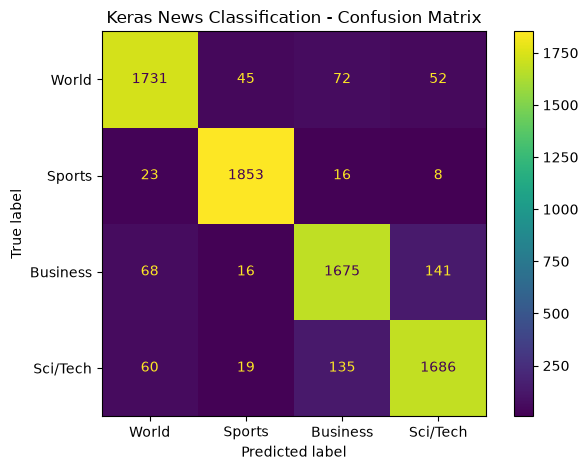

In [22]:
import matplotlib.pyplot as plt

keras_cm = confusion_matrix(
    y_test,
    keras_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=keras_cm,
    display_labels=class_names
)

disp.plot()

plt.title(
    "Keras News Classification - Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [23]:
from pathlib import Path
import pandas as pd

results_dir = Path("../results/metrics")
results_dir.mkdir(parents=True, exist_ok=True)

keras_report_dict = classification_report(
    y_test,
    keras_predictions,
    target_names=class_names,
    output_dict=True
)

keras_report_df = pd.DataFrame(
    keras_report_dict
).transpose()

keras_report_df.to_csv(
    results_dir / "keras_classification_report.csv"
)

print("Keras classification report saved.")

Keras classification report saved.


In [24]:
keras_cm_df = pd.DataFrame(
    keras_cm,
    index=class_names,
    columns=class_names
)

keras_cm_df.to_csv(
    results_dir / "keras_confusion_matrix.csv"
)

print("Keras confusion matrix saved.")

Keras confusion matrix saved.


In [25]:
predictions_dir = Path("../results/predictions")
predictions_dir.mkdir(parents=True, exist_ok=True)

keras_prediction_df = pd.DataFrame({
    "true_label": [
        class_names[label]
        for label in y_test
    ],
    "predicted_label": [
        class_names[prediction]
        for prediction in keras_predictions
    ]
})

keras_prediction_df.to_csv(
    predictions_dir / "keras_test_predictions.csv",
    index=False
)

print("Keras predictions saved.")

Keras predictions saved.


In [26]:
comparison_data = {
    "Metric": [
        "Test Accuracy",
        "Test Loss",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],
    "PyTorch": [
        0.9118421053,
        0.2667369462,
        0.91,
        0.91,
        0.91
    ],
    "Keras": [
        0.9138157964,
        0.2630495429,
        0.91,
        0.91,
        0.91
    ]
}

comparison_df = pd.DataFrame(comparison_data)

comparison_df.to_csv(
    "../results/metrics/pytorch_vs_keras_comparison.csv",
    index=False
)

comparison_df

,Metric,PyTorch,Keras
0,Test Accuracy,0.911842,0.913816
1,Test Loss,0.266737,0.263050
2,Macro Precision,0.910000,0.910000
3,Macro Recall,0.910000,0.910000
4,Macro F1,0.910000,0.910000


<Figure size 800x600 with 0 Axes>

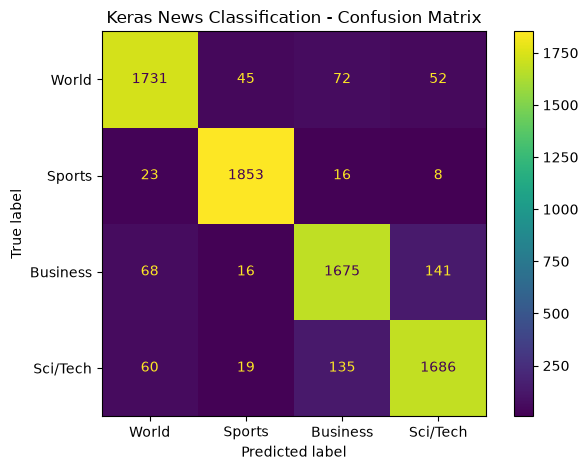

In [27]:
plots_dir = Path("../results/plots")
plots_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=keras_cm,
    display_labels=class_names
)

disp.plot()

plt.title(
    "Keras News Classification - Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    plots_dir / "keras_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

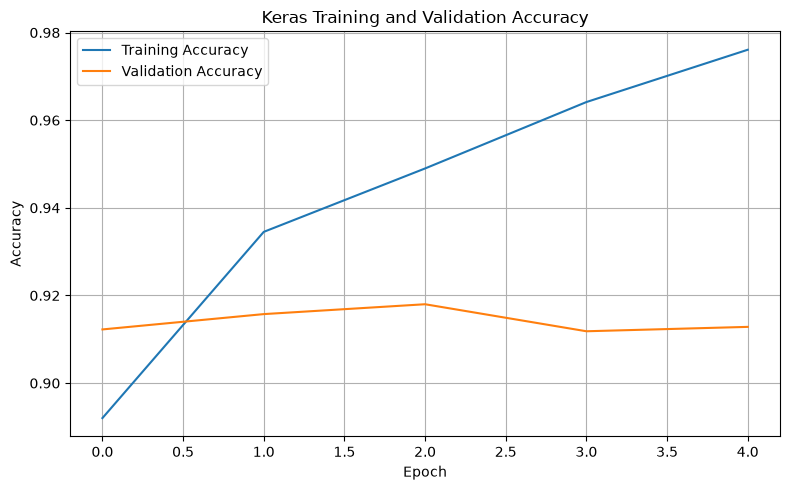

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_keras.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_keras.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Keras Training and Validation Accuracy"
)

plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    plots_dir / "keras_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

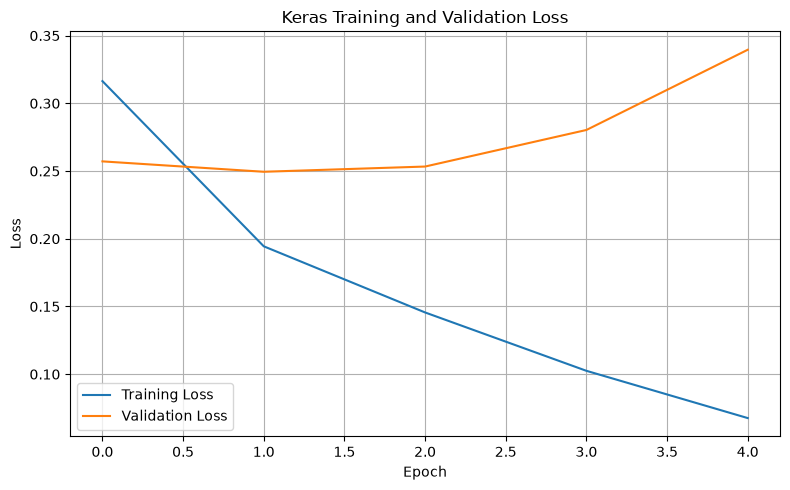

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_keras.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_keras.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Keras Training and Validation Loss"
)

plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    plots_dir / "keras_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()